<a href="https://colab.research.google.com/github/smtmn0/AminaS/blob/main/%D0%9C%D0%9E_%D0%9C%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D0%BA%D0%B0_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика Машиналық оқытуға қажетті базалық Математика


**Мақсат:** Бұл практикалық жұмыста студенттер машиналық оқытуда кеңінен қолданылатын математикалық аппаратты — сызықтық алгебра, ықтималдық теориясы, статистика және нормализация әдістерін Python арқылы меңгереді.

**Нұсқау:** Әр ұяшықтағы `# TODO` белгісін тауып, тапсырманы орындаңыз. Код ұяшықтарын кезекпен іске қосыңыз.

| Студент | Орындайтын тапсырма |
| :--- | :--- |
| Амангелді Мейірім | 1.1, 2.1, 3.1, 4.1, 5.1 |
| Ахат Аңсаған | 1.2, 2.2, 3.2, 4.2, 5.2 |
| Бахрам Бексұлтан | 1.3, 2.3, 3.3, 4.3, 5.3 |
| Даирова Нұрсұлу | 1.4, 2.4, 3.4, 4.4, 5.4 |
| Жумадилов Дияр | 1.5, 2.5, 3.5, 4.5, 5.5 |
| Жүнісова Әсел | 1.6, 2.6, 3.6, 4.6, 5.6 |
| Кинаятов Наурызбай | 1.7, 2.7, 3.7, 4.7, 5.7 |
| Манапалы Жанерке | 1.8, 2.8, 3.8, 4.8, 5.8 |
| Саматқызы Амина | 1.9, 2.9, 3.9, 4.9, 5.9 |

In [ ]:
# Қажетті кітапханаларды импорттау
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, normalize
import warnings
warnings.filterwarnings('ignore')

# Нәтижелердің қайталануын қамтамасыз ету
np.random.seed(42)
print("Кітапханалар сәтті жүктелді!")

# 1-БӨЛІМ: Векторлар және матрицалар

**Мақсат:** Векторлар мен матрицалардың негізгі операцияларын Python-да орындауды үйрену.

## Теориялық анықтама

**Вектор**  скалярлардың реттелген жиыны. $n$-өлшемді вектор:

$$\mathbf{x} = (x_1, x_2, \ldots, x_n)^T \in \mathbb{R}^n$$

**Матрица**  $m \times n$ өлшемді тіктөртбұрышты массив:

$$A = \begin{pmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{pmatrix}$$

**Скалярлық көбейтінді (dot product):**

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta$$

In [11]:
# Тапсырма 1.9: Матрицаның дәрежесі мен ізі
# Rank және trace — матрица қасиеттерін сипаттайтын маңызды шамалар

A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
B = np.array([[1, 0, 0], [0, 2, 0], [0, 0, 3]])

# TODO: A матрицасының дәрежесін (rank) есептеңіз
rank_A = np.linalg.matrix_rank(A)

# TODO: B матрицасының ізін (trace) — диагональ элементтер қосындысын есептеңіз
trace_B = np.trace(B)

# TODO: B матрицасының Frobenius нормасын есептеңіз
frobenius_norm =  np.linalg.norm(B, 'fro')

print("A матрицасының дәрежесі:", rank_A)
print("B матрицасының ізі:", trace_B)
print("B матрицасының Frobenius нормасы:", frobenius_norm)

A матрицасының дәрежесі: 2
B матрицасының ізі: 6
B матрицасының Frobenius нормасы: 3.7416573867739413


# 2-БӨЛІМ: Векторлық нормалар

**Мақсат:** Машиналық оқытудың реттеу (regularization) әдістерінде қолданылатын нормаларды есептеуді меңгеру.

## Теориялық анықтама

**L1 норма (Manhattan):**

$$\|\mathbf{x}\|_1 = \sum_{i=1}^{n} |x_i|$$

**L2 норма (Euclidean):**

$$\|\mathbf{x}\|_2 = \sqrt{\sum_{i=1}^{n} x_i^2}$$

**L$\infty$ норма (Chebyshev):**

$$\|\mathbf{x}\|_{\infty} = \max_i |x_i|$$

Lasso регрессиясы L1 нормасын, Ridge регрессиясы L2 нормасын қолданады.

In [12]:
# Тапсырма 2.9: Вектордың проекциясы
# a векторының b бағытына проекциясы
# proj_b(a) = (a · b / ||b||^2) * b

def vector_projection(a, b):
    # TODO: a векторының b бағытына проекциясын есептеңіз
    scalar_proj = np.dot(a, b) / np.dot(b, b)
    vector_proj =  scalar_proj * b
    return vector_proj

a = np.array([3.0, 2.0])
b = np.array([1.0, 0.0])

proj = vector_projection(a, b)
print("a векторы:", a)
print("b векторы:", b)
print("a-ның b-ға проекциясы:", proj)

a векторы: [3. 2.]
b векторы: [1. 0.]
a-ның b-ға проекциясы: [3. 0.]



# 3-БӨЛІМ: Ықтималдық теориясы негіздері

**Мақсат:** Машиналық оқытудағы байесиандық тәсілдер мен ықтималдық модельдерінің негізін қалайтын ықтималдық теориясын меңгеру.

## Теориялық анықтама

**Байес теоремасы:**

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

$P(A|B)$ — Шартты ықтималдық: $B$ жаңа оқиғасы орындалып қойған кездегі $A$ оқиғасының ықтималдығы (біздің жаңартылған болжамымыз).

$P(A)$ — Априорлық ықтималдық: Жаңа мәліметті білмей тұрғандағы $A$-ның бастапқы ықтималдығы.

**Математикалық үміт:**

Кездейсоқ шаманың күтілетін "орташа" мәні. Бұл алгоритм ұзақ мерзімде немесе үлкен мәліметтер жиынтығында қандай нәтижеге қол жеткізетінін көрсетеді.

$$E[X] = \sum_{x} x \cdot P(X = x)$$

Қарапайым тілмен: Мұндағы әрбір мүмкін мән ($x$) өзінің кездесу ықтималдығына ($P(X = x)$) көбейтіліп, бір-біріне қосылады.


**Дисперсия:**


Мәліметтердің орташа мәннен (математикалық үміттен) қаншалықты ауытқитынын көрсетеді. Дисперсия неғұрлым жоғары болса, мәліметтер соғұрлым тұрақсыз әрі шашыраңқы болады. Бұл модельдің қателіктерін бағалауда маңызды рөл атқарады.

$$\text{Var}(X) = E[(X - E[X])^2] = E[X^2] - (E[X])^2$$



**Ковариация:**

Екі түрлі айнымалының (мәліметтердегі екі түрлі бағанның) бірге қалай өзгеретінін көрсетеді. Машиналық оқытуда бұл бір-бірін қайталайтын, артық белгілерді (features) тауып, алып тастау үшін қажет.

$$\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$



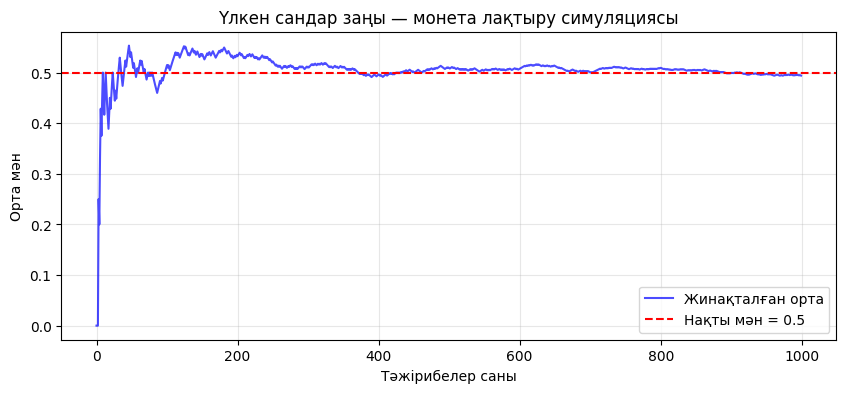

In [14]:
# Тапсырма 3.9: Үлкен сандар заңы
# Таңдама өлшемі ұлғайған сайын орта мән нақты мәнге жақындайды
import matplotlib.pyplot as plt
true_mean = 0.5   # p=0.5 монета лақтыру нәтижесі
n_max = 1000

# TODO: np.random.binomial(1, true_mean, n_max) арқылы монета лақтыру симуляциясын орындаңыз
flips =  np.random.binomial(1, true_mean, n_max)

# TODO: 1-ден n_max-ке дейін жиіліктің жинақталған орта мәнін есептеңіз
# Кеңес: np.cumsum(flips) / np.arange(1, n_max+1)
cumulative_means =  np.cumsum(flips) / np.arange(1, n_max + 1)

if cumulative_means is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(cumulative_means, color='blue', alpha=0.7, label='Жинақталған орта')
    plt.axhline(true_mean, color='red', linestyle='--', label=f'Нақты мән = {true_mean}')
    plt.xlabel("Тәжірибелер саны")
    plt.ylabel("Орта мән")
    plt.title("Үлкен сандар заңы — монета лақтыру симуляциясы")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# 4-БӨЛІМ: Статистикалық таралымдар

**Мақсат:** Машиналық оқытуда кеңінен қолданылатын негізгі статистикалық таралымдарды зерттеу және олардың қасиеттерін меңгеру.

## Теориялық анықтама

**Қалыпты (нормаль) таралым:**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Экспоненциалды таралым:**

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**68-95-99.7 ережесі:** Нормаль таралымда деректердің 68% $\mu \pm \sigma$, 95% $\mu \pm 2\sigma$, 99.7% $\mu \pm 3\sigma$ аралығында орналасады.

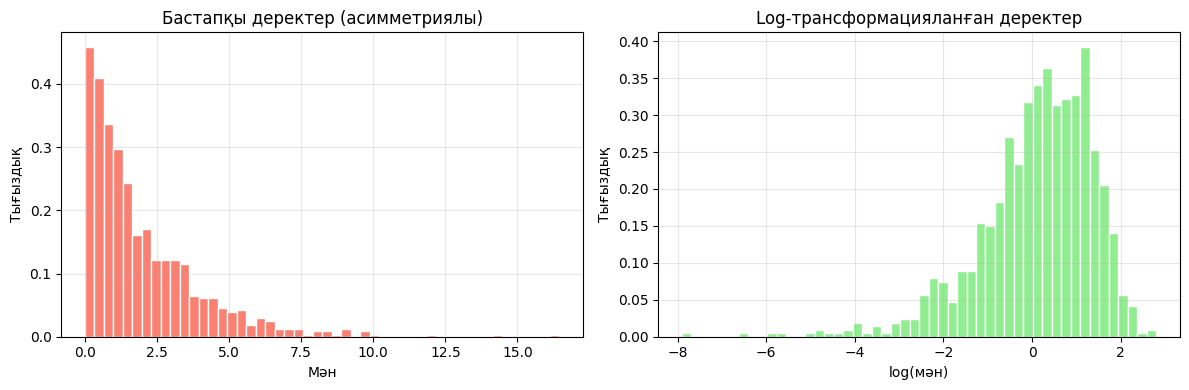

NameError: name 'stats' is not defined

In [15]:
# Тапсырма 4.9: Деректерді трансформациялау — нормальдылыққа жақындату
# Log трансформация асимметриялық деректерді нормальдандырады

np.random.seed(7)
skewed_data = np.random.exponential(scale=2, size=1000)

# TODO: натуралды логарифм арқылы деректерді трансформациялаңыз
log_data = np.log(skewed_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(skewed_data, bins=50, color='salmon', edgecolor='white', density=True)
axes[0].set_title("Бастапқы деректер (асимметриялы)")
axes[0].set_xlabel("Мән")
axes[0].set_ylabel("Тығыздық")
axes[0].grid(alpha=0.3)

if log_data is not None:
    axes[1].hist(log_data, bins=50, color='lightgreen', edgecolor='white', density=True)
axes[1].set_title("Log-трансформацияланған деректер")
axes[1].set_xlabel("log(мән)")
axes[1].set_ylabel("Тығыздық")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# TODO: екі деректер жиынының асимметрия (skewness) көрсеткіштерін есептеңіз
print(f"Бастапқы деректер асимметриясы: {stats.skew(skewed_data):.4f}")
print(f"Log-трансформация асимметриясы: {stats.skew(log_data):.4f}" if log_data is not None else "Log-трансформация: TODO")


# 5-БӨЛІМ: Деректерді нормализациялау әдістері

**Мақсат:** Машиналық оқыту алгоритмдерінің дұрыс жұмыс істеуі үшін деректерді алдын ала өңдеу тәсілдерін меңгеру.

## Теориялық анықтама

**Min-Max нормализациясы:**

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0, 1]$$

**Z-score стандарттау:**

$$x_{\text{std}} = \frac{x - \mu}{\sigma}$$

**Robust нормализация:**

$$x_{\text{robust}} = \frac{x - \text{медиана}}{\text{IQR}}$$

IQR (Interquartile Range) — 75-ші және 25-ші перцентильдердің айырмасы. Аномалиялы мәндерге тұрақты.

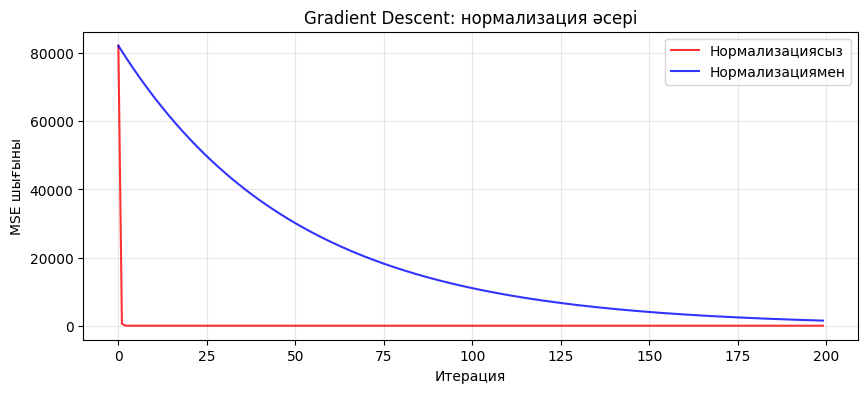

In [17]:
# Тапсырма 5.9: Нормализациясыз vs нормализациямен — Gradient Descent
# Нормализацияның оқыту жылдамдығына әсерін бақылаңыз
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
def gradient_descent(X, y, lr=0.01, n_iterations=100):
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = []
    for _ in range(n_iterations):
        # TODO: болжамды есептеңіз: y_pred = X @ theta
        y_pred = X @ theta
        # TODO: қатені есептеңіз: error = y_pred - y
        error = y_pred - y
        # TODO: MSE шығынын есептеңіз: loss = mean(error^2)
        loss = np.mean(error**2)
        # TODO: градиентті есептеңіз: gradient = X.T @ error / m
        gradient = X.T @ error / m
        # TODO: параметрлерді жаңартыңыз: theta -= lr * gradient
        if y_pred is not None and gradient is not None:
            theta -= lr * gradient
            loss_history.append(loss)
    return theta, loss_history

np.random.seed(42)
X_raw = np.random.randn(200, 2) * np.array([100, 1])
y = 3 * X_raw[:, 0] + 5 * X_raw[:, 1] + np.random.randn(200)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

_, loss_raw = gradient_descent(X_raw, y, lr=0.0001, n_iterations=200)
_, loss_scaled = gradient_descent(X_scaled, y, lr=0.01, n_iterations=200)

plt.figure(figsize=(10, 4))
if loss_raw:
    plt.plot(loss_raw, 'r-', label='Нормализациясыз', alpha=0.8)
if loss_scaled:
    plt.plot(loss_scaled, 'b-', label='Нормализациямен', alpha=0.8)
plt.xlabel("Итерация")
plt.ylabel("MSE шығыны")
plt.title("Gradient Descent: нормализация әсері")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Қорытынды

Осы практикалық жұмыста сіз келесі тақырыптарды меңгердіңіз:

**1-бөлім:** Векторлар мен матрицалардың негізгі операциялары, SVD ыдырату, меншікті мәндер

**2-бөлім:** L1, L2, L-inf нормалары, Евклидтік және Манхэттен қашықтықтары, косинустық ұқсастық

**3-бөлім:** Байес теоремасы, математикалық үміт, дисперсия, ковариация, Монте-Карло

**4-бөлім:** Нормаль, биномдық, Пуассон, t-, chi-квадрат таралымдары; гипотезаларды тексеру

**5-бөлім:** Min-Max, Z-score, Robust нормализациялары; train/test жиындарын дұрыс өңдеу

Бұл математикалық негіз машиналық оқытудың барлық алгоритмдерінде регрессиядан бастап терең желілерге дейін қолданылады.